# Trustworthy AI Week 2 Lab — NLP Adversarial Attacks on SMS Spam Classifier

This notebook implements the Week 2 lab workflow end-to-end:

1. Load SMS Spam Collection dataset
2. Preprocess SMS text
3. Train a clean spam classifier
4. Evaluate clean performance
5. Create adversarial text attacks
6. Verify that attacks actually modify text
7. Evaluate clean vs attacked performance
8. Build defenses using normalization
9. Apply adversarial training
10. Export slide-ready tables and charts

## Main Trustworthy AI Focus

A high-performing NLP classifier may fail when attackers make small surface-level text changes that preserve human meaning but break model features.

## AI Usage Declaration

AI tools were used for implementation support, debugging assistance, and workflow guidance. All experimental methodology, analytical interpretation, conclusions, and Trustworthy AI reflections should be independently reviewed, validated, and refined by the team.

## 0. Setup

This notebook uses a simple and explainable baseline:

**TF-IDF + Logistic Regression**

This is intentional. The goal is to study adversarial text perturbations and tokenization fragility, not to optimize for state-of-the-art spam detection.

In [3]:
# If running in a fresh environment, uncomment these:
# !pip install pandas numpy scikit-learn matplotlib seaborn requests

import os
import re
import json
import random
import zipfile
from pathlib import Path
from urllib.request import urlretrieve
from urllib.error import URLError, HTTPError

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

OUTPUT_DIR = Path("week2_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Setup completed.")

Setup completed.


## 1. Research Questions

"RQ1: Does high clean accuracy translate into robustness against adversarial SMS perturbations?"

"RQ2: Which text perturbations are most effective at bypassing the spam classifier?"

"RQ3: Can normalization and character cleanup recover performance?"

"RQ4: Does adversarial training improve robustness, and what trade-off does it introduce?"

"RQ5: What does this imply for trustworthy deployment of NLP classifiers?"

## 2. Load SMS Spam Collection Dataset

The primary dataset source is UCI. A GitHub mirror fallback is included to improve reproducibility if the UCI link is unavailable.

In [4]:
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

zip_path = DATA_DIR / "smsspamcollection.zip"
sms_file = DATA_DIR / "SMSSpamCollection"

DATASET_URLS = [
    "https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip",
    "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv",
]

def download_dataset():
    if sms_file.exists():
        print(f"Dataset already exists at: {sms_file}")
        return sms_file

    last_error = None

    # Try UCI zip first
    try:
        print("Trying UCI ZIP download...")
        urlretrieve(DATASET_URLS[0], zip_path)
        with zipfile.ZipFile(zip_path, "r") as z:
            z.extractall(DATA_DIR)
        if sms_file.exists():
            print("Downloaded and extracted UCI dataset.")
            return sms_file
    except Exception as e:
        last_error = e
        print(f"UCI download failed: {e}")

    # Try GitHub TSV mirror
    try:
        print("Trying GitHub TSV mirror...")
        tsv_path = DATA_DIR / "sms.tsv"
        urlretrieve(DATASET_URLS[1], tsv_path)
        df_tmp = pd.read_csv(tsv_path, sep="\t", header=None, names=["label", "message"])
        df_tmp.to_csv(sms_file, sep="\t", header=False, index=False)
        print("Downloaded GitHub mirror and converted to SMSSpamCollection format.")
        return sms_file
    except Exception as e:
        last_error = e
        print(f"GitHub mirror failed: {e}")

    raise RuntimeError(f"Could not download dataset. Last error: {last_error}")

dataset_path = download_dataset()

df = pd.read_csv(dataset_path, sep="\t", header=None, names=["label", "message"])
df["label_num"] = df["label"].map({"ham": 0, "spam": 1})

print(df.shape)
display(df.head())
display(df["label"].value_counts().to_frame("count"))

Dataset already exists at: data/SMSSpamCollection
(5572, 3)


,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


,count
label,
ham,4825
spam,747


## 3. Text Preprocessing

Two preprocessors are used:

1. `basic_preprocess`: clean baseline preprocessing.
2. `defensive_preprocess`: maps leetspeak digits back to letters before punctuation removal.

Important fix: punctuation such as `!`, `@`, `$` is **not** mapped into letters. It is removed normally, preventing corruption like `money!!! → moneyiii`.

In [5]:
def normalize_whitespace(text: str) -> str:
    return re.sub(r"\s+", " ", text).strip()

def basic_preprocess(text: str) -> str:
    """Lowercase, remove punctuation/symbols, normalize whitespace."""
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = normalize_whitespace(text)
    return text

LEET_DIGIT_MAP = str.maketrans({
    "0": "o",
    "1": "i",
    "3": "e",
    "4": "a",
    "5": "s",
    "7": "t",
})

def defensive_preprocess(text: str) -> str:
    """
    Defensive preprocessing for common leetspeak.
    Only maps digits that commonly substitute letters.
    Punctuation is not translated into letters.
    """
    text = str(text).lower()
    text = text.translate(LEET_DIGIT_MAP)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = normalize_whitespace(text)
    return text

# Defensive preprocessing sanity check
sample = "FREE money!!! Claim pr1ze n0w!!!"
print("Original :", sample)
print("Basic    :", basic_preprocess(sample))
print("Defensive:", defensive_preprocess(sample))

assert "moneyiii" not in defensive_preprocess(sample), "Defense preprocessing is corrupting punctuation."

Original : FREE money!!! Claim pr1ze n0w!!!
Basic    : free money claim pr1ze n0w
Defensive: free money claim prize now


## 4. Train/Test Split

We use stratified splitting so that spam/ham proportions are preserved.

In [6]:
X = df["message"].astype(str)
y = df["label_num"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print("Train size:", len(X_train))
print("Test size :", len(X_test))
print("Train spam rate:", y_train.mean())
print("Test spam rate :", y_test.mean())

Train size: 4457
Test size : 1115
Train spam rate: 0.13417096701817366
Test spam rate : 0.1336322869955157


## 5. Baseline Model: TF-IDF + Logistic Regression

This model is deliberately interpretable and fast. It also makes tokenization fragility easy to observe.

Reference - scikit-learn TfidfVectorizer Documentation

In [7]:
def make_pipeline(preprocessor=basic_preprocess):
    return Pipeline([
        ("tfidf", TfidfVectorizer(
            preprocessor=preprocessor,
            tokenizer=None,
            token_pattern=r"(?u)\b\w\w+\b",
            ngram_range=(1, 2),
            min_df=2,
        )),
        ("clf", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=SEED
        )),
    ])

baseline_model = make_pipeline(preprocessor=basic_preprocess)
baseline_model.fit(X_train, y_train)

print("Baseline model trained.")

Baseline model trained.


## 6. Evaluation Utilities

For this lab, the most important metric is **spam slip-through rate**:

\[
\text{Slip-through} = 1 - \text{Spam Recall}
\]

This measures how much spam bypasses the classifier and gets predicted as ham.

In [8]:
def evaluate_model(model, X_eval, y_eval, condition_name="Condition"):
    preds = model.predict(X_eval)

    acc = accuracy_score(y_eval, preds)
    precision = precision_score(y_eval, preds, zero_division=0)
    recall = recall_score(y_eval, preds, zero_division=0)
    f1 = f1_score(y_eval, preds, zero_division=0)

    cm = confusion_matrix(y_eval, preds, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    slip_through = fn / (fn + tp) if (fn + tp) > 0 else np.nan
    false_positive_rate = fp / (fp + tn) if (fp + tn) > 0 else np.nan

    return {
        "condition": condition_name,
        "accuracy": acc,
        "spam_precision": precision,
        "spam_recall": recall,
        "spam_slip_through": slip_through,
        "false_positive_rate": false_positive_rate,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
    }

def display_metrics_row(metrics):
    return pd.DataFrame([metrics]).round(4)

clean_metrics = evaluate_model(baseline_model, X_test, y_test, "Clean baseline")
display(display_metrics_row(clean_metrics))

print(classification_report(y_test, baseline_model.predict(X_test), target_names=["ham", "spam"]))

,condition,accuracy,spam_precision,spam_recall,spam_slip_through,false_positive_rate,tn,fp,fn,tp
0,Clean baseline,0.983,0.9452,0.9262,0.0738,0.0083,958,8,11,138


              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       966
        spam       0.95      0.93      0.94       149

    accuracy                           0.98      1115
   macro avg       0.97      0.96      0.96      1115
weighted avg       0.98      0.98      0.98      1115



## 7. Define Adversarial Text Attacks

The attacks simulate surface-level perturbations where the message meaning remains understandable to humans but tokenization/features may change.

Attack types:
- Keyword obfuscation
- Homoglyph / leetspeak substitutions
- Spacing attack
- Mixed attack

In [9]:
SPAM_KEYWORD_REPLACEMENTS = {
    "free": "fr33",
    "money": "m0ney",
    "cash": "ca$h",
    "claim": "cl@im",
    "prize": "pr1ze",
    "winner": "w1nner",
    "win": "w1n",
    "urgent": "urg3nt",
    "call": "c@ll",
    "text": "t3xt",
    "txt": "tx7",
    "reply": "r3ply",
    "offer": "0ffer",
    "guaranteed": "guarant33d",
    "selected": "s3lected",
    "bonus": "b0nus",
}

HOMOGLYPH_MAP = str.maketrans({
    "a": "@",
    "e": "3",
    "i": "1",
    "o": "0",
    "s": "$",
})

def replace_whole_word(text: str, word: str, replacement: str) -> str:
    # Correct word boundary usage: raw f-string with \b.
    pattern = rf"\b{re.escape(word)}\b"
    return re.sub(pattern, replacement, text, flags=re.IGNORECASE)

def keyword_obfuscation(text: str) -> str:
    attacked = str(text)
    for word, repl in SPAM_KEYWORD_REPLACEMENTS.items():
        attacked = replace_whole_word(attacked, word, repl)
    return attacked

def homoglyph_attack(text: str) -> str:
    """
    Apply homoglyph/leetspeak substitution only to spam-like keywords,
    preserving readability while breaking lexical features.
    """
    attacked = str(text)
    for word in SPAM_KEYWORD_REPLACEMENTS.keys():
        def repl_fn(match):
            return match.group(0).translate(HOMOGLYPH_MAP)
        attacked = re.sub(rf"\b{re.escape(word)}\b", repl_fn, attacked, flags=re.IGNORECASE)
    return attacked

def spacing_attack(text: str) -> str:
    """
    Insert spaces inside selected spam keywords.
    Example: free -> f r e e
    """
    attacked = str(text)
    spacing_words = ["free", "winner", "win", "cash", "prize", "claim", "urgent", "offer"]
    for word in spacing_words:
        spaced = " ".join(list(word))
        attacked = re.sub(rf"\b{re.escape(word)}\b", spaced, attacked, flags=re.IGNORECASE)
    return attacked

def mixed_attack(text: str) -> str:
    attacked = keyword_obfuscation(text)
    attacked = homoglyph_attack(attacked)
    # Apply spacing to original keywords that may remain.
    attacked = spacing_attack(attacked)
    return attacked

ATTACKS = {
    "Keyword obfuscation": keyword_obfuscation,
    "Homoglyph": homoglyph_attack,
    "Spacing": spacing_attack,
    "Mixed": mixed_attack,
}

print("Attack functions defined.")

Attack functions defined.


## 8. Attack Diagnostic Table

This is a fail-fast check. It proves that the attack functions actually modify text before we run the experiment.

If this table shows `changed = False`, the attack engine is broken and evaluation results are not meaningful.

In [10]:
diagnostic_text = "WINNER!! Claim your free prize cash now"

diagnostic_rows = []
for attack_name, attack_fn in ATTACKS.items():
    attacked = attack_fn(diagnostic_text)
    diagnostic_rows.append({
        "attack": attack_name,
        "before": diagnostic_text,
        "after": attacked,
        "changed": diagnostic_text != attacked,
    })

diagnostic_df = pd.DataFrame(diagnostic_rows)
display(diagnostic_df)

# Fail fast if any attack does nothing to the diagnostic text.
assert diagnostic_df["changed"].all(), "One or more attacks did not modify the diagnostic text."

diagnostic_df.to_csv(OUTPUT_DIR / "attack_diagnostic_table.csv", index=False)
print("Diagnostic table saved.")

,attack,before,after,changed
0,Keyword obfuscation,WINNER!! Claim your free prize cash now,w1nner!! cl@im your fr33 pr1ze ca$h now,True
1,Homoglyph,WINNER!! Claim your free prize cash now,WINNER!! Cl@1m your fr33 pr1z3 c@$h now,True
2,Spacing,WINNER!! Claim your free prize cash now,w i n n e r!! c l a i m your f r e e p r i z e...,True
3,Mixed,WINNER!! Claim your free prize cash now,w1nner!! cl@im your fr33 pr1ze ca$h now,True


Diagnostic table saved.


## 9. Attack Coverage on Actual Test Set

The diagnostic sentence is not enough. We also verify how many real test messages were changed by each attack.

Important:
- Some ham messages may not contain spam keywords and may remain unchanged.
- For this lab, the key check is the **spam message change rate**, because the attacker primarily wants spam to slip through.

In [11]:
def compute_change_rates(original_texts, attacked_texts, labels):
    original_arr = np.array(list(original_texts), dtype=object)
    attacked_arr = np.array(list(attacked_texts), dtype=object)
    labels_arr = np.array(list(labels))

    changed = original_arr != attacked_arr

    overall_change_rate = changed.mean()
    spam_mask = labels_arr == 1
    ham_mask = labels_arr == 0

    spam_change_rate = changed[spam_mask].mean() if spam_mask.sum() else np.nan
    ham_change_rate = changed[ham_mask].mean() if ham_mask.sum() else np.nan

    return overall_change_rate, spam_change_rate, ham_change_rate

coverage_rows = []

for attack_name, attack_fn in ATTACKS.items():
    attacked_texts = X_test.apply(attack_fn)
    overall_rate, spam_rate, ham_rate = compute_change_rates(X_test, attacked_texts, y_test)

    coverage_rows.append({
        "attack": attack_name,
        "overall_message_change_rate": overall_rate,
        "spam_message_change_rate": spam_rate,
        "ham_message_change_rate": ham_rate,
    })

coverage_df = pd.DataFrame(coverage_rows).round(4)
display(coverage_df)

coverage_df.to_csv(OUTPUT_DIR / "attack_coverage_table.csv", index=False)

# Fail fast if an attack does not affect any spam messages.
for _, row in coverage_df.iterrows():
    assert row["spam_message_change_rate"] > 0, f"{row['attack']} did not modify any spam messages."

print("Attack coverage check passed.")

,attack,overall_message_change_rate,spam_message_change_rate,ham_message_change_rate
0,Keyword obfuscation,0.1883,0.8591,0.0849
1,Homoglyph,0.1731,0.7584,0.0828
2,Spacing,0.0888,0.5369,0.0197
3,Mixed,0.1883,0.8591,0.0849


Attack coverage check passed.


## 10. Evaluate Adversarial Attacks

We compare:
- Clean baseline
- Keyword obfuscation
- Homoglyph
- Spacing
- Mixed

Expected security pattern:

**Accuracy decreases, spam recall decreases, and spam slip-through increases.**

In [13]:
attack_results = [clean_metrics]
attacked_cache = {}

for attack_name, attack_fn in ATTACKS.items():
    X_attacked = X_test.apply(attack_fn)
    attacked_cache[attack_name] = X_attacked

    metrics = evaluate_model(
        baseline_model,
        X_attacked,
        y_test,
        condition_name=attack_name
    )

    overall_rate, spam_rate, ham_rate = compute_change_rates(X_test, X_attacked, y_test)
    metrics["overall_message_change_rate"] = overall_rate
    metrics["spam_message_change_rate"] = spam_rate
    metrics["ham_message_change_rate"] = ham_rate

    attack_results.append(metrics)

attack_results_df = pd.DataFrame(attack_results).round(4)
display(attack_results_df)

attack_results_df.to_csv(OUTPUT_DIR / "attack_results.csv", index=False)
print("Attack results saved.")

,condition,accuracy,spam_precision,spam_recall,spam_slip_through,false_positive_rate,tn,fp,fn,tp,overall_message_change_rate,spam_message_change_rate,ham_message_change_rate
0,Clean baseline,0.9830,0.9452,0.9262,0.0738,0.0083,958,8,11,138,NaN,NaN,NaN
1,Keyword obfuscation,0.9758,0.9621,0.8523,0.1477,0.0052,961,5,22,127,0.1883,0.8591,0.0849
2,Homoglyph,0.9785,0.9630,0.8725,0.1275,0.0052,961,5,19,130,0.1731,0.7584,0.0828
3,Spacing,0.9812,0.9444,0.9128,0.0872,0.0083,958,8,13,136,0.0888,0.5369,0.0197
4,Mixed,0.9758,0.9621,0.8523,0.1477,0.0052,961,5,22,127,0.1883,0.8591,0.0849


Attack results saved.


## 11. Verify Attack Rows Against Clean Baseline

This cell checks whether attacks caused a meaningful robustness gap.

An attack row should generally show:
- Lower spam recall than clean baseline
- Higher spam slip-through than clean baseline

Spacing attacks may be weaker, but at least keyword/homoglyph/mixed attacks should show degradation.

In [14]:
clean_row = attack_results_df[attack_results_df["condition"] == "Clean baseline"].iloc[0]
attack_only_df = attack_results_df[attack_results_df["condition"] != "Clean baseline"].copy()

comparison_rows = []
for _, row in attack_only_df.iterrows():
    recall_drop = clean_row["spam_recall"] - row["spam_recall"]
    slip_increase = row["spam_slip_through"] - clean_row["spam_slip_through"]
    accuracy_drop = clean_row["accuracy"] - row["accuracy"]

    comparison_rows.append({
        "attack": row["condition"],
        "accuracy_drop_vs_clean": accuracy_drop,
        "spam_recall_drop_vs_clean": recall_drop,
        "slip_through_increase_vs_clean": slip_increase,
        "passes_expected_pattern": (recall_drop > 0) and (slip_increase > 0),
    })

attack_vs_clean_df = pd.DataFrame(comparison_rows).round(4)
display(attack_vs_clean_df)

attack_vs_clean_df.to_csv(OUTPUT_DIR / "attack_vs_clean_verification.csv", index=False)

# Strong attacks should degrade the model. Spacing can sometimes be weaker.
must_degrade = ["Keyword obfuscation", "Homoglyph", "Mixed"]
for attack in must_degrade:
    row = attack_vs_clean_df[attack_vs_clean_df["attack"] == attack].iloc[0]
    assert row["spam_recall_drop_vs_clean"] > 0, f"{attack} did not reduce spam recall."
    assert row["slip_through_increase_vs_clean"] > 0, f"{attack} did not increase spam slip-through."

print("Attack-vs-clean verification passed for key attacks.")

,attack,accuracy_drop_vs_clean,spam_recall_drop_vs_clean,slip_through_increase_vs_clean,passes_expected_pattern
0,Keyword obfuscation,0.0072,0.0739,0.0739,True
1,Homoglyph,0.0045,0.0537,0.0537,True
2,Spacing,0.0018,0.0134,0.0134,True
3,Mixed,0.0072,0.0739,0.0739,True


Attack-vs-clean verification passed for key attacks.


## 12. Successful Attack Examples

These are spam messages that were correctly detected as spam when clean, but slipped through as ham after attack.

This table is highly useful for slides because it shows the attack in human-readable form.

In [15]:
def get_successful_attack_examples(model, X_original, X_attacked, y_true, attack_name, n=8):
    clean_preds = model.predict(X_original)
    attacked_preds = model.predict(X_attacked)

    rows = []
    for original, attacked, y, clean_pred, adv_pred in zip(
        X_original, X_attacked, y_true, clean_preds, attacked_preds
    ):
        if y == 1 and clean_pred == 1 and adv_pred == 0 and original != attacked:
            rows.append({
                "attack": attack_name,
                "original_spam": original,
                "attacked_spam": attacked,
                "clean_prediction": "spam",
                "attacked_prediction": "ham",
            })

    return pd.DataFrame(rows).head(n)

example_frames = []
for attack_name, X_attacked in attacked_cache.items():
    ex = get_successful_attack_examples(
        baseline_model,
        X_test.reset_index(drop=True),
        X_attacked.reset_index(drop=True),
        y_test.reset_index(drop=True),
        attack_name,
        n=5,
    )
    example_frames.append(ex)

successful_examples_df = pd.concat(example_frames, ignore_index=True) if example_frames else pd.DataFrame()

if successful_examples_df.empty:
    print("No successful attack examples found. Check attack strength or model robustness.")
else:
    display(successful_examples_df)

successful_examples_df.to_csv(OUTPUT_DIR / "successful_attack_examples.csv", index=False)

,attack,original_spam,attacked_spam,clean_prediction,attacked_prediction
0,Keyword obfuscation,Dear Voucher Holder 2 claim your 1st class air...,Dear Voucher Holder 2 cl@im your 1st class air...,spam,ham
1,Keyword obfuscation,Sunshine Quiz! Win a super Sony DVD recorder i...,Sunshine Quiz! w1n a super Sony DVD recorder i...,spam,ham
2,Keyword obfuscation,"Claim a 200 shopping spree, just call 08717895...","cl@im a 200 shopping spree, just c@ll 08717895...",spam,ham
3,Keyword obfuscation,More people are dogging in your area now. Call...,More people are dogging in your area now. c@ll...,spam,ham
4,Keyword obfuscation,I'd like to tell you my deepest darkest fantas...,I'd like to tell you my deepest darkest fantas...,spam,ham
5,Homoglyph,Dear Voucher Holder 2 claim your 1st class air...,Dear Voucher Holder 2 cl@1m your 1st class air...,spam,ham
6,Homoglyph,Sunshine Quiz! Win a super Sony DVD recorder i...,Sunshine Quiz! W1n a super Sony DVD recorder i...,spam,ham
7,Homoglyph,"Claim a 200 shopping spree, just call 08717895...","Cl@1m a 200 shopping spree, just c@ll 08717895...",spam,ham
8,Homoglyph,More people are dogging in your area now. Call...,More people are dogging in your area now. C@ll...,spam,ham
9,Homoglyph,I'd like to tell you my deepest darkest fantas...,I'd like to tell you my deepest darkest fantas...,spam,ham


## 13. Defense 1 — Normalization / Character Mapping Cleanup

This defense maps common leetspeak digits back into letters before vectorization.

Example:
- `fr33` → `free`
- `m0ney` → `money`
- `pr1ze` → `prize`

It is not a complete defense, but it should recover some robustness against surface-level attacks.

In [16]:
defensive_model = make_pipeline(preprocessor=defensive_preprocess)
defensive_model.fit(X_train, y_train)

defense_results = []

# Clean performance under defensive preprocessing
defense_results.append(
    evaluate_model(defensive_model, X_test, y_test, "Defense model - clean")
)

for attack_name, X_attacked in attacked_cache.items():
    defense_results.append(
        evaluate_model(defensive_model, X_attacked, y_test, f"Defense model - {attack_name}")
    )

defense_results_df = pd.DataFrame(defense_results).round(4)
display(defense_results_df)

defense_results_df.to_csv(OUTPUT_DIR / "defense_normalization_results.csv", index=False)

,condition,accuracy,spam_precision,spam_recall,spam_slip_through,false_positive_rate,tn,fp,fn,tp
0,Defense model - clean,0.9821,0.9448,0.9195,0.0805,0.0083,958,8,12,137
1,Defense model - Keyword obfuscation,0.9803,0.9568,0.8926,0.1074,0.0062,960,6,16,133
2,Defense model - Homoglyph,0.9803,0.9568,0.8926,0.1074,0.0062,960,6,16,133
3,Defense model - Spacing,0.9803,0.9441,0.9060,0.0940,0.0083,958,8,14,135
4,Defense model - Mixed,0.9803,0.9568,0.8926,0.1074,0.0062,960,6,16,133


## 14. Defense 2 — Adversarial Training

We augment the training set with mixed-attack versions of spam messages.

This tests whether retraining on adversarial examples improves robustness.

In [17]:
# Create adversarial training data from spam messages in the training set
train_df = pd.DataFrame({"message": X_train.values, "label": y_train.values})
spam_train_df = train_df[train_df["label"] == 1].copy()

adv_spam_train_df = spam_train_df.copy()
adv_spam_train_df["message"] = adv_spam_train_df["message"].apply(mixed_attack)

augmented_train_df = pd.concat([
    train_df,
    adv_spam_train_df
], ignore_index=True)

print("Original train size :", len(train_df))
print("Adversarial spam added:", len(adv_spam_train_df))
print("Augmented train size:", len(augmented_train_df))

adv_trained_model = make_pipeline(preprocessor=defensive_preprocess)
adv_trained_model.fit(augmented_train_df["message"], augmented_train_df["label"])

adv_train_results = []
adv_train_results.append(
    evaluate_model(adv_trained_model, X_test, y_test, "Adv-trained model - clean")
)

for attack_name, X_attacked in attacked_cache.items():
    adv_train_results.append(
        evaluate_model(adv_trained_model, X_attacked, y_test, f"Adv-trained model - {attack_name}")
    )

adv_train_results_df = pd.DataFrame(adv_train_results).round(4)
display(adv_train_results_df)

adv_train_results_df.to_csv(OUTPUT_DIR / "adversarial_training_results.csv", index=False)

Original train size : 4457
Adversarial spam added: 598
Augmented train size: 5055


,condition,accuracy,spam_precision,spam_recall,spam_slip_through,false_positive_rate,tn,fp,fn,tp
0,Adv-trained model - clean,0.9848,0.9648,0.9195,0.0805,0.0052,961,5,12,137
1,Adv-trained model - Keyword obfuscation,0.9848,0.9648,0.9195,0.0805,0.0052,961,5,12,137
2,Adv-trained model - Homoglyph,0.9848,0.9648,0.9195,0.0805,0.0052,961,5,12,137
3,Adv-trained model - Spacing,0.9839,0.9645,0.9128,0.0872,0.0052,961,5,13,136
4,Adv-trained model - Mixed,0.9848,0.9648,0.9195,0.0805,0.0052,961,5,12,137


## 15. Consolidated Results Table

This table is designed for slide generation.

In [18]:
# Prepare compact rows for the key conditions
compact_rows = []

def add_compact_row(df_metrics, condition_label, source_label=None):
    row = df_metrics[df_metrics["condition"] == condition_label].iloc[0]
    compact_rows.append({
        "condition": source_label or condition_label,
        "accuracy": row["accuracy"],
        "spam_recall": row["spam_recall"],
        "spam_slip_through": row["spam_slip_through"],
    })

add_compact_row(attack_results_df, "Clean baseline")
for attack in ATTACKS.keys():
    add_compact_row(attack_results_df, attack)

# Add adversarially trained mixed attack
mixed_adv_row = adv_train_results_df[
    adv_train_results_df["condition"] == "Adv-trained model - Mixed"
].iloc[0]
compact_rows.append({
    "condition": "Adv-trained, mixed attack",
    "accuracy": mixed_adv_row["accuracy"],
    "spam_recall": mixed_adv_row["spam_recall"],
    "spam_slip_through": mixed_adv_row["spam_slip_through"],
})

compact_results_df = pd.DataFrame(compact_rows).round(4)
display(compact_results_df)

compact_results_df.to_csv(OUTPUT_DIR / "slide_ready_compact_results.csv", index=False)

,condition,accuracy,spam_recall,spam_slip_through
0,Clean baseline,0.9830,0.9262,0.0738
1,Keyword obfuscation,0.9758,0.8523,0.1477
2,Homoglyph,0.9785,0.8725,0.1275
3,Spacing,0.9812,0.9128,0.0872
4,Mixed,0.9758,0.8523,0.1477
5,"Adv-trained, mixed attack",0.9848,0.9195,0.0805


## 16. Visualizations

The notebook exports charts that can be inserted directly into the slide deck.

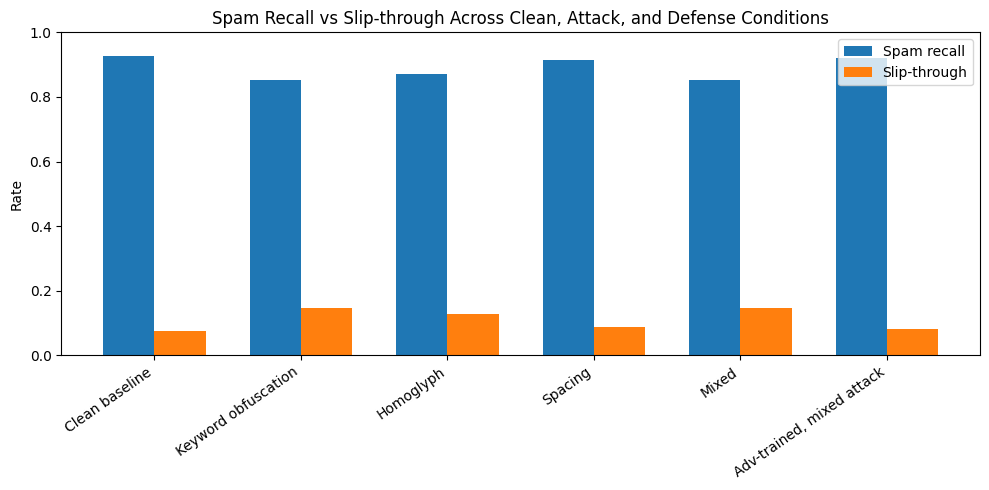

Saved: week2_outputs/spam_recall_vs_slipthrough.png


In [19]:
# Chart 1: Spam recall and slip-through by condition
plot_df = compact_results_df.copy()

plt.figure(figsize=(10, 5))
x = np.arange(len(plot_df))
width = 0.35

plt.bar(x - width/2, plot_df["spam_recall"], width, label="Spam recall")
plt.bar(x + width/2, plot_df["spam_slip_through"], width, label="Slip-through")

plt.xticks(x, plot_df["condition"], rotation=35, ha="right")
plt.ylim(0, 1)
plt.ylabel("Rate")
plt.title("Spam Recall vs Slip-through Across Clean, Attack, and Defense Conditions")
plt.legend()
plt.tight_layout()

chart_path = OUTPUT_DIR / "spam_recall_vs_slipthrough.png"
plt.savefig(chart_path, dpi=200)
plt.show()

print(f"Saved: {chart_path}")

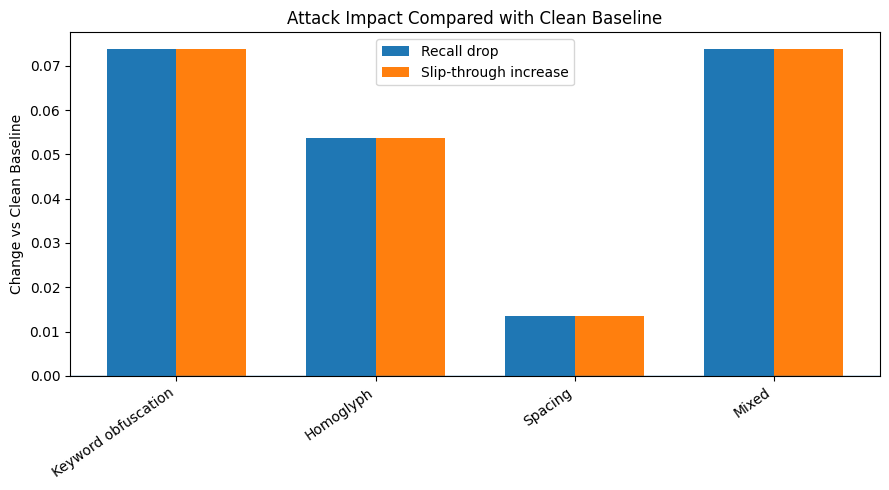

Saved: week2_outputs/attack_impact_vs_clean.png


In [20]:
# Chart 2: Attack-vs-clean degradation
plt.figure(figsize=(9, 5))
x = np.arange(len(attack_vs_clean_df))
width = 0.35

plt.bar(x - width/2, attack_vs_clean_df["spam_recall_drop_vs_clean"], width, label="Recall drop")
plt.bar(x + width/2, attack_vs_clean_df["slip_through_increase_vs_clean"], width, label="Slip-through increase")

plt.xticks(x, attack_vs_clean_df["attack"], rotation=35, ha="right")
plt.ylabel("Change vs Clean Baseline")
plt.title("Attack Impact Compared with Clean Baseline")
plt.axhline(0, linewidth=1)
plt.legend()
plt.tight_layout()

chart_path = OUTPUT_DIR / "attack_impact_vs_clean.png"
plt.savefig(chart_path, dpi=200)
plt.show()

print(f"Saved: {chart_path}")

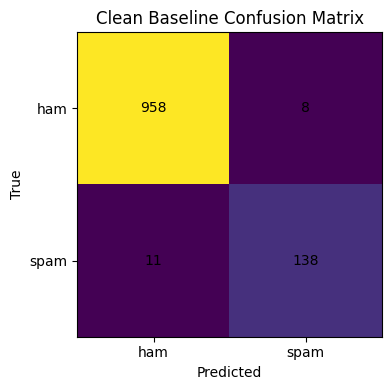

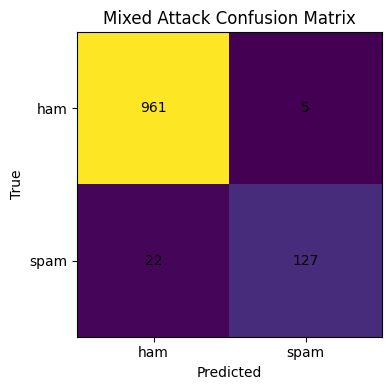

In [21]:
# Confusion matrices for clean and mixed attack
def plot_confusion_matrix(cm, title, path):
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["ham", "spam"])
    ax.set_yticklabels(["ham", "spam"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)

    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")

    fig.tight_layout()
    fig.savefig(path, dpi=200)
    plt.show()

clean_preds = baseline_model.predict(X_test)
clean_cm = confusion_matrix(y_test, clean_preds, labels=[0, 1])
plot_confusion_matrix(clean_cm, "Clean Baseline Confusion Matrix", OUTPUT_DIR / "confusion_matrix_clean.png")

mixed_preds = baseline_model.predict(attacked_cache["Mixed"])
mixed_cm = confusion_matrix(y_test, mixed_preds, labels=[0, 1])
plot_confusion_matrix(mixed_cm, "Mixed Attack Confusion Matrix", OUTPUT_DIR / "confusion_matrix_mixed_attack.png")

## 17. Slide-Ready Interpretation Prompts

Use these to generate the slide deck notes.

In [22]:
interpretation = {
    "main_finding": (
        "The clean spam classifier achieved high baseline accuracy, but adversarial perturbations "
        "reduced spam recall and increased spam slip-through, showing that clean accuracy alone "
        "does not guarantee robustness."
    ),
    "attack_finding": (
        "Keyword obfuscation, homoglyph substitutions, and mixed attacks were more damaging than "
        "spacing alone because they directly disrupted spam-indicative tokens while preserving "
        "human-readable meaning."
    ),
    "defense_finding": (
        "Normalization and adversarial training recovered some robustness, but did not eliminate "
        "the adversarial risk. This demonstrates the trade-off between defensive preprocessing, "
        "attack coverage, and generalization to unseen perturbations."
    ),
    "trustworthy_ai_implication": (
        "For deployment, spam filters and other NLP classifiers require robustness evaluation, "
        "input normalization, monitoring for drift or obfuscation patterns, and periodic retraining. "
        "A system can appear accurate under clean testing while remaining fragile under adversarial usage."
    )
}

for k, v in interpretation.items():
    print(f"{k}:")
    print(v)
    print()

with open(OUTPUT_DIR / "slide_ready_interpretation.json", "w") as f:
    json.dump(interpretation, f, indent=2)

print("Interpretation prompts saved.")

main_finding:
The clean spam classifier achieved high baseline accuracy, but adversarial perturbations reduced spam recall and increased spam slip-through, showing that clean accuracy alone does not guarantee robustness.

attack_finding:
Keyword obfuscation, homoglyph substitutions, and mixed attacks were more damaging than spacing alone because they directly disrupted spam-indicative tokens while preserving human-readable meaning.

defense_finding:
Normalization and adversarial training recovered some robustness, but did not eliminate the adversarial risk. This demonstrates the trade-off between defensive preprocessing, attack coverage, and generalization to unseen perturbations.

trustworthy_ai_implication:
For deployment, spam filters and other NLP classifiers require robustness evaluation, input normalization, monitoring for drift or obfuscation patterns, and periodic retraining. A system can appear accurate under clean testing while remaining fragile under adversarial usage.

Inte

## 18. Reflection Prompts

Each team member should write their own reflection.

Suggested prompts:
- What surprised you most about NLP adversarial attacks?
- Why is clean accuracy insufficient?
- Why do small text changes fool the model while humans still understand the message?
- What are the limits of normalization and adversarial training?
- What does this imply for real-world AI deployment and governance?

## 19. Final Checklist Before Submission

Run this checklist before submitting the notebook:

- Diagnostic table shows all attacks changed the sample sentence.
- Spam message change rate is greater than 0 for each attack.
- Attack rows are not identical to the clean baseline.
- Key attacks reduce spam recall and increase slip-through.
- Defense and adversarial training results are generated.
- Charts and CSV files are exported in `week2_outputs/`.
- Reflection is written independently by each member.

In [21]:
print("Generated files:")
for path in sorted(OUTPUT_DIR.glob("*")):
    print("-", path)

Generated files:
- week2_outputs/adversarial_training_results.csv
- week2_outputs/attack_coverage_table.csv
- week2_outputs/attack_diagnostic_table.csv
- week2_outputs/attack_impact_vs_clean.png
- week2_outputs/attack_results.csv
- week2_outputs/attack_vs_clean_verification.csv
- week2_outputs/confusion_matrix_clean.png
- week2_outputs/confusion_matrix_mixed_attack.png
- week2_outputs/defense_normalization_results.csv
- week2_outputs/figures
- week2_outputs/slide_ready_compact_results.csv
- week2_outputs/slide_ready_interpretation.json
- week2_outputs/slide_ready_summary.md
- week2_outputs/spam_recall_vs_slipthrough.png
- week2_outputs/successful_attack_examples.csv
- week2_outputs/tables
